In [1]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/chatgpt_reviews.csv")
df.head()

,Review Id,Review,Ratings,Review Date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39


In [4]:
df.columns = df.columns.str.lower().str.strip()

df['review'] = df['review'].fillna("")

df['ratings'] = pd.to_numeric(df['ratings'], errors='coerce')

In [5]:
from textblob import TextBlob

def get_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity, analysis.sentiment.subjectivity

df[['polarity', 'subjectivity']] = df['review'].apply(lambda x: pd.Series(get_sentiment(x)))

In [6]:
def label_sentiment(score):
    if score > 0:
        return "Positive"
    elif score == 0:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['polarity'].apply(label_sentiment)

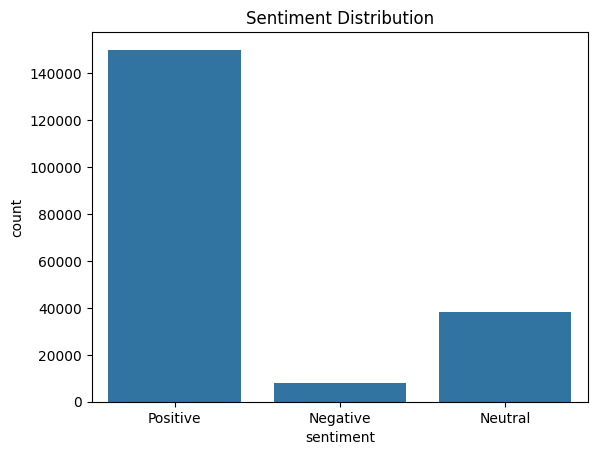

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

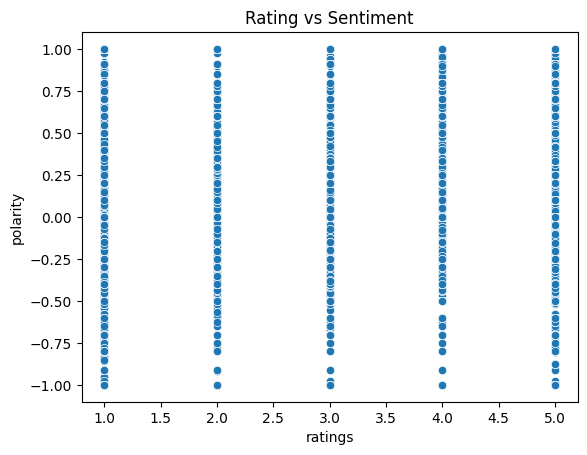

In [9]:
sns.scatterplot(x='ratings', y='polarity', data=df)
plt.title("Rating vs Sentiment")
plt.show()

In [10]:
from collections import Counter
import re

positive_reviews = df[df['sentiment'] == "Positive"]['review']

words = []

for review in positive_reviews:
    review = re.sub(r'[^\w\s]', '', review.lower())
    words.extend(review.split())

common_words = Counter(words).most_common(20)
print(common_words)

[('app', 44207), ('it', 41412), ('good', 39061), ('the', 36779), ('very', 35212), ('and', 34447), ('i', 33292), ('is', 32765), ('to', 30341), ('this', 25259), ('a', 23017), ('for', 22734), ('its', 20345), ('best', 18315), ('nice', 13719), ('in', 13691), ('of', 13002), ('you', 11984), ('great', 11875), ('my', 11066)]


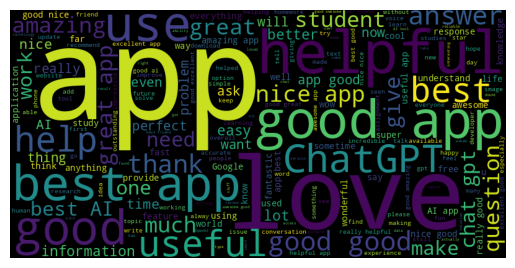

In [11]:
from wordcloud import WordCloud

text = " ".join(positive_reviews)

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.show()